# Phase 4 — Driver Analysis: What Affects Final 3-Minute Scoring?

Building on P6 snapshot PPM from notebook 03, this notebook analyzes how
specific team characteristics of the **leading** and **trailing** teams
affect endgame scoring rates.

### Drivers
1. **Leading team OREB** — more offensive rebounds = more second-chance possessions
2. **Trailing team 3PT volume** — trailing teams may increase 3PA to close the gap
3. **Trailing team 3PT efficiency** — better shooters make up ground faster
4. **Leading team pace** (sec/poss) — slower teams burn more clock
5. **Trailing team pace** — faster trailing teams create more scoring opportunities

---

## 0 — Setup & Load Data

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEASON = 2024
DATA_DIR = os.path.join(os.getcwd(), 'data')

pbp      = pq.read_table(os.path.join(DATA_DIR, f'pbp_{SEASON}.parquet')).to_pandas()
team_box = pq.read_table(os.path.join(DATA_DIR, f'team_box_{SEASON}.parquet')).to_pandas()
schedule = pq.read_table(os.path.join(DATA_DIR, f'schedule_{SEASON}.parquet')).to_pandas()

print(f'PBP: {pbp.shape[0]:,} rows ({pbp["game_id"].nunique():,} games)')
print(f'Team Box: {team_box.shape[0]:,} rows')
print(f'Schedule: {schedule.shape[0]:,} rows')

PBP: 2,004,997 rows (6,151 games)
Team Box: 12,480 rows
Schedule: 6,249 rows


---
## 1 — Power 6 Filter

In [2]:
# ── Conference mapping (reuse from NB03) ──
gmap = schedule[['groups_id', 'groups_short_name']].drop_duplicates().dropna()
gmap['groups_id'] = gmap['groups_id'].astype(int)
conf_id_to_name = gmap.set_index('groups_id')['groups_short_name'].to_dict()

home = schedule[['home_id','home_conference_id']].rename(columns={'home_id':'team_id','home_conference_id':'conf_id'})
away = schedule[['away_id','away_conference_id']].rename(columns={'away_id':'team_id','away_conference_id':'conf_id'})
all_teams = pd.concat([home, away]).dropna(subset=['conf_id'])
all_teams['conf_id'] = all_teams['conf_id'].astype(int)
team_conf = all_teams.groupby('team_id')['conf_id'].agg(lambda x: x.mode().iloc[0]).reset_index()
team_conf['conf'] = team_conf['conf_id'].map(conf_id_to_name)

POWER_6 = ['ACC', 'Big 12', 'Big East', 'Big Ten', 'Pac-12', 'SEC']
p6_ids = set(team_conf[team_conf['conf'].isin(POWER_6)]['team_id'])

p6_games = schedule[
    schedule['home_id'].isin(p6_ids) & schedule['away_id'].isin(p6_ids)
]['game_id'].unique()

pbp_p6 = pbp[pbp['game_id'].isin(p6_games)].copy()
print(f'P6 teams: {len(p6_ids)} | P6-vs-P6 games: {len(p6_games):,}')

P6 teams: 80 | P6-vs-P6 games: 1,041


In [3]:
# ── Regulation data ──
reg = pbp_p6[pbp_p6['period_number'].isin([1, 2])].copy()
reg['home_score'] = pd.to_numeric(reg['home_score'], errors='coerce').fillna(0).astype(int)
reg['away_score'] = pd.to_numeric(reg['away_score'], errors='coerce').fillna(0).astype(int)
reg['score_value'] = pd.to_numeric(reg['score_value'], errors='coerce').fillna(0).astype(int)
reg['secs_remaining'] = pd.to_numeric(reg['end_game_seconds_remaining'], errors='coerce')
reg['margin'] = reg['home_score'] - reg['away_score']
reg = reg.sort_values(['game_id', 'sequence_number']).reset_index(drop=True)

def margin_bucket(m):
    if pd.isna(m): return None
    m = int(m)
    if   m > 15:          return 'Leading >15'
    elif 10 <= m <= 15:   return 'Leading 10-15'
    elif 5  <= m <= 9:    return 'Leading 5-9'
    elif 1  <= m <= 4:    return 'Leading 1-4'
    elif m == 0:          return 'Tied'
    elif -4 <= m <= -1:   return 'Trailing 1-4'
    elif -9 <= m <= -5:   return 'Trailing 5-9'
    elif -15 <= m <= -10: return 'Trailing 10-15'
    else:                 return 'Trailing >15'

BUCKET_ORDER = [
    'Leading >15', 'Leading 10-15', 'Leading 5-9', 'Leading 1-4',
    'Tied',
    'Trailing 1-4', 'Trailing 5-9', 'Trailing 10-15', 'Trailing >15'
]

n_games = reg['game_id'].nunique()
print(f'Regulation: {len(reg):,} events, {n_games:,} games')

Regulation: 335,045 events, 1,041 games


---
## 2 — Team Season Stats & Driver Quartiles

Compute season-level averages from **all games** (full schedule),
then bucket into quartiles.

In [4]:
# ── Compute per-game stats from team_box ──
tb = team_box.copy()
for col in ['offensive_rebounds', 'defensive_rebounds',
            'three_point_field_goals_made', 'three_point_field_goals_attempted',
            'field_goals_attempted', 'turnovers', 'free_throws_attempted',
            'team_score', 'opponent_team_score']:
    tb[col] = pd.to_numeric(tb[col], errors='coerce')

tb['three_pt_pct'] = pd.to_numeric(tb['three_point_field_goal_pct'], errors='coerce')
tb['possessions'] = (tb['field_goals_attempted'] - tb['offensive_rebounds']
                     + tb['turnovers'] + 0.475 * tb['free_throws_attempted'])
tb['sec_per_poss'] = 40 * 60 / tb['possessions']

# Season-level averages per team
team_stats = tb.groupby('team_id').agg(
    avg_oreb=('offensive_rebounds', 'mean'),
    avg_3pa=('three_point_field_goals_attempted', 'mean'),
    avg_3pt_pct=('three_pt_pct', 'mean'),
    avg_sec_per_poss=('sec_per_poss', 'mean'),
    avg_poss=('possessions', 'mean'),
    games=('game_id', 'nunique'),
    team_name=('team_display_name', 'first'),
).reset_index()

# Filter to stable teams
team_stats = team_stats[team_stats['games'] >= 10].copy()

# Assign quartiles for each driver
DRIVERS = {
    'avg_oreb':         ('OREB Q', True),    # higher = more boards = Q1
    'avg_3pa':          ('3PA Q',  True),     # higher volume = Q1
    'avg_3pt_pct':      ('3P% Q',  True),     # higher pct = Q1
    'avg_sec_per_poss': ('Pace Q', False),    # LOWER sec/poss = faster = Q1
}

for col, (q_name, ascending_is_q1) in DRIVERS.items():
    if ascending_is_q1:
        # Higher value = Q1 (best), so we reverse the labels
        team_stats[q_name] = pd.qcut(
            team_stats[col], q=4,
            labels=['Q4 (Low)', 'Q3', 'Q2', 'Q1 (High)']
        )
    else:
        # Lower value = Q1 (fastest)
        team_stats[q_name] = pd.qcut(
            team_stats[col], q=4,
            labels=['Q1 (Fast)', 'Q2', 'Q3', 'Q4 (Slow)']
        )

print(f'Teams with season stats: {len(team_stats)}')
print(f'\n=== Driver Distributions ===')
for col, (q_name, _) in DRIVERS.items():
    print(f'\n{q_name} ({col}):')
    desc = team_stats.groupby(q_name)[col].agg(['count', 'mean', 'min', 'max']).round(2)
    print(desc.to_string())

Teams with season stats: 362

=== Driver Distributions ===

OREB Q (avg_oreb):
           count   mean    min    max
OREB Q                               
Q4 (Low)      92   8.16   5.70   9.16
Q3            89   9.70   9.16  10.12
Q2            90  10.75  10.15  11.39
Q1 (High)     91  12.48  11.39  17.42

3PA Q (avg_3pa):
           count   mean    min    max
3PA Q                                
Q4 (Low)      91  17.92  13.88  19.74
Q3            90  20.85  19.78  21.88
Q2            91  22.95  21.92  23.94
Q1 (High)     90  26.07  23.97  33.22

3P% Q (avg_3pt_pct):
           count   mean    min    max
3P% Q                                
Q4 (Low)      91  30.61  24.85  32.23
Q3            90  33.10  32.24  33.94
Q2            90  34.71  33.97  35.53
Q1 (High)     91  36.68  35.53  40.32

Pace Q (avg_sec_per_poss):
           count   mean    min    max
Pace Q                               
Q1 (Fast)     91  33.27  31.69  34.04
Q2            90  34.48  34.07  34.85
Q3            90 

In [5]:
# ── Show P6 teams' driver stats ──
p6_stats = team_stats[team_stats['team_id'].isin(p6_ids)].copy()
print(f'P6 teams with stats: {len(p6_stats)}')

print(f'\n=== P6 Team Driver Averages ===')
for col in ['avg_oreb', 'avg_3pa', 'avg_3pt_pct', 'avg_sec_per_poss']:
    print(f'  {col:<20} mean={p6_stats[col].mean():.2f}  min={p6_stats[col].min():.2f}  max={p6_stats[col].max():.2f}')

P6 teams with stats: 80

=== P6 Team Driver Averages ===
  avg_oreb             mean=10.51  min=7.28  max=17.42
  avg_3pa              mean=22.15  min=15.55  max=31.97
  avg_3pt_pct          mean=34.43  min=27.94  max=40.32
  avg_sec_per_poss     mean=34.83  min=32.36  max=39.17


---
## 3 — Identify Leading & Trailing Teams at 3:00 Mark

In [6]:
# ── Snapshot margin at 180s and assign leading/trailing team IDs ──
def get_entry_info(reg_df, window_secs):
    pre = reg_df[reg_df['secs_remaining'] >= window_secs]
    entry = pre.groupby('game_id').last()
    return entry[['margin', 'home_team_id', 'away_team_id', 'home_score', 'away_score']]

entry_3 = get_entry_info(reg, 180)
entry_3['margin_bucket'] = entry_3['margin'].apply(margin_bucket)

# Leading = home if margin > 0, away if margin < 0
entry_3['leading_team_id'] = np.where(
    entry_3['margin'] > 0, entry_3['home_team_id'],
    np.where(entry_3['margin'] < 0, entry_3['away_team_id'], np.nan)
)
entry_3['trailing_team_id'] = np.where(
    entry_3['margin'] > 0, entry_3['away_team_id'],
    np.where(entry_3['margin'] < 0, entry_3['home_team_id'], np.nan)
)

# Drop ties (no leading/trailing in ties)
entry_3_lt = entry_3[entry_3['margin'] != 0].copy()
entry_3_lt['abs_margin'] = entry_3_lt['margin'].abs()

print(f'Total games at 3:00 mark: {len(entry_3):,}')
print(f'  With leader/trailer:    {len(entry_3_lt):,}')
print(f'  Tied (excluded):        {(entry_3["margin"]==0).sum():,}')
print(f'\n=== Margin Bucket Distribution ===')
for b in BUCKET_ORDER:
    cnt = (entry_3['margin_bucket'] == b).sum()
    print(f'  {b:<20} {cnt:>5}')

Total games at 3:00 mark: 1,041
  With leader/trailer:    943
  Tied (excluded):        98

=== Margin Bucket Distribution ===
  Leading >15            192
  Leading 10-15          159
  Leading 5-9            117
  Leading 1-4            129
  Tied                    98
  Trailing 1-4            86
  Trailing 5-9           104
  Trailing 10-15          80
  Trailing >15            76


---
## 4 — Merge Driver Quartiles into Game Data

In [7]:
# ── Build lookup dicts for each driver quartile ──
driver_lookups = {}
for col, (q_name, _) in DRIVERS.items():
    driver_lookups[q_name] = team_stats.set_index('team_id')[q_name].to_dict()

# ── Map driver quartiles for leading and trailing teams ──
for q_name, lookup in driver_lookups.items():
    entry_3_lt[f'lead_{q_name}'] = entry_3_lt['leading_team_id'].map(lookup)
    entry_3_lt[f'trail_{q_name}'] = entry_3_lt['trailing_team_id'].map(lookup)

# Show coverage
for q_name in driver_lookups:
    lead_cov = entry_3_lt[f'lead_{q_name}'].notna().mean()
    trail_cov = entry_3_lt[f'trail_{q_name}'].notna().mean()
    print(f'{q_name}: lead coverage={lead_cov:.1%}, trail coverage={trail_cov:.1%}')

OREB Q: lead coverage=100.0%, trail coverage=100.0%
3PA Q: lead coverage=100.0%, trail coverage=100.0%
3P% Q: lead coverage=100.0%, trail coverage=100.0%
Pace Q: lead coverage=100.0%, trail coverage=100.0%


---
## 5 — PPM by Driver Quartile (Final 3 Minutes)

For each driver, compute total PPM in the final 3 minutes,
bucketed by the leading or trailing team's quartile for that stat.

In [8]:
# ── Get all F3 scoring events ──
scoring_3 = reg[(reg['scoring_play'] == True) & (reg['secs_remaining'] <= 180)].copy()
scoring_3['entry_bucket'] = scoring_3['game_id'].map(entry_3['margin_bucket'])
scoring_3 = scoring_3.dropna(subset=['entry_bucket'])

# Only non-tied games
scoring_3_lt = scoring_3[scoring_3['game_id'].isin(entry_3_lt.index)].copy()

# Merge driver quartiles into scoring events
for q_name in driver_lookups:
    scoring_3_lt[f'lead_{q_name}'] = scoring_3_lt['game_id'].map(
        entry_3_lt[f'lead_{q_name}'])
    scoring_3_lt[f'trail_{q_name}'] = scoring_3_lt['game_id'].map(
        entry_3_lt[f'trail_{q_name}'])

print(f'F3 scoring events (non-tied): {len(scoring_3_lt):,}')
print(f'Games: {scoring_3_lt["game_id"].nunique():,}')

F3 scoring events (non-tied): 9,237
Games: 942


In [9]:
# ── PPM computation by driver quartile ──
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#e0e0e0', 'ytick.color': '#e0e0e0',
    'font.size': 11, 'axes.titlesize': 14, 'figure.titlesize': 16,
})

DRIVER_CONFIGS = [
    ('lead_OREB Q',  'Leading Team OREB',  ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('trail_3PA Q',  'Trailing Team 3PA Volume', ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('trail_3P% Q',  'Trailing Team 3P%',  ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('lead_Pace Q',  'Leading Team Pace',  ['Q1 (Fast)','Q2','Q3','Q4 (Slow)']),
    ('trail_Pace Q', 'Trailing Team Pace', ['Q1 (Fast)','Q2','Q3','Q4 (Slow)']),
]

all_driver_results = []

for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    s_valid = scoring_3_lt.dropna(subset=[driver_col])
    games_valid = entry_3_lt.dropna(subset=[driver_col])
    
    pts_by_q = s_valid.groupby(driver_col)['score_value'].sum()
    games_by_q = games_valid[driver_col].value_counts()
    
    rows = []
    for q in q_labels:
        pts = pts_by_q.get(q, 0)
        n_g = games_by_q.get(q, 0)
        ppm = pts / (n_g * 3) if n_g > 0 else 0
        rows.append({'Driver': driver_label, 'Quartile': q, 'Games': n_g,
                     'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    all_driver_results.extend(rows)

driver_df = pd.DataFrame(all_driver_results)

print('=== PPM by Driver Quartile — Final 3 Minutes (P6, non-tied) ===')
for driver_label in driver_df['Driver'].unique():
    print(f'\n--- {driver_label} ---')
    sub = driver_df[driver_df['Driver'] == driver_label][['Quartile','Games','Total Pts','PPM']]
    display(sub.reset_index(drop=True))

=== PPM by Driver Quartile — Final 3 Minutes (P6, non-tied) ===

--- Leading Team OREB ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),336,5191,5.150
1,Q2,154,2339,5.063
2,Q3,269,4020,4.981
3,Q4 (Low),184,2858,5.178



--- Trailing Team 3PA Volume ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),186,2810,5.036
1,Q2,313,5008,5.333
2,Q3,221,3368,5.080
3,Q4 (Low),223,3222,4.816



--- Trailing Team 3P% ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),273,4230,5.165
1,Q2,237,3657,5.143
2,Q3,246,3602,4.881
3,Q4 (Low),187,2919,5.203



--- Leading Team Pace ---


,Quartile,Games,Total Pts,PPM
0,Q1 (Fast),235,3782,5.365
1,Q2,234,3661,5.215
2,Q3,260,3975,5.096
3,Q4 (Slow),214,2990,4.657



--- Trailing Team Pace ---


,Quartile,Games,Total Pts,PPM
0,Q1 (Fast),208,3288,5.269
1,Q2,264,3953,4.991
2,Q3,304,4620,5.066
3,Q4 (Slow),167,2547,5.084


---
## 6 — Visualizations

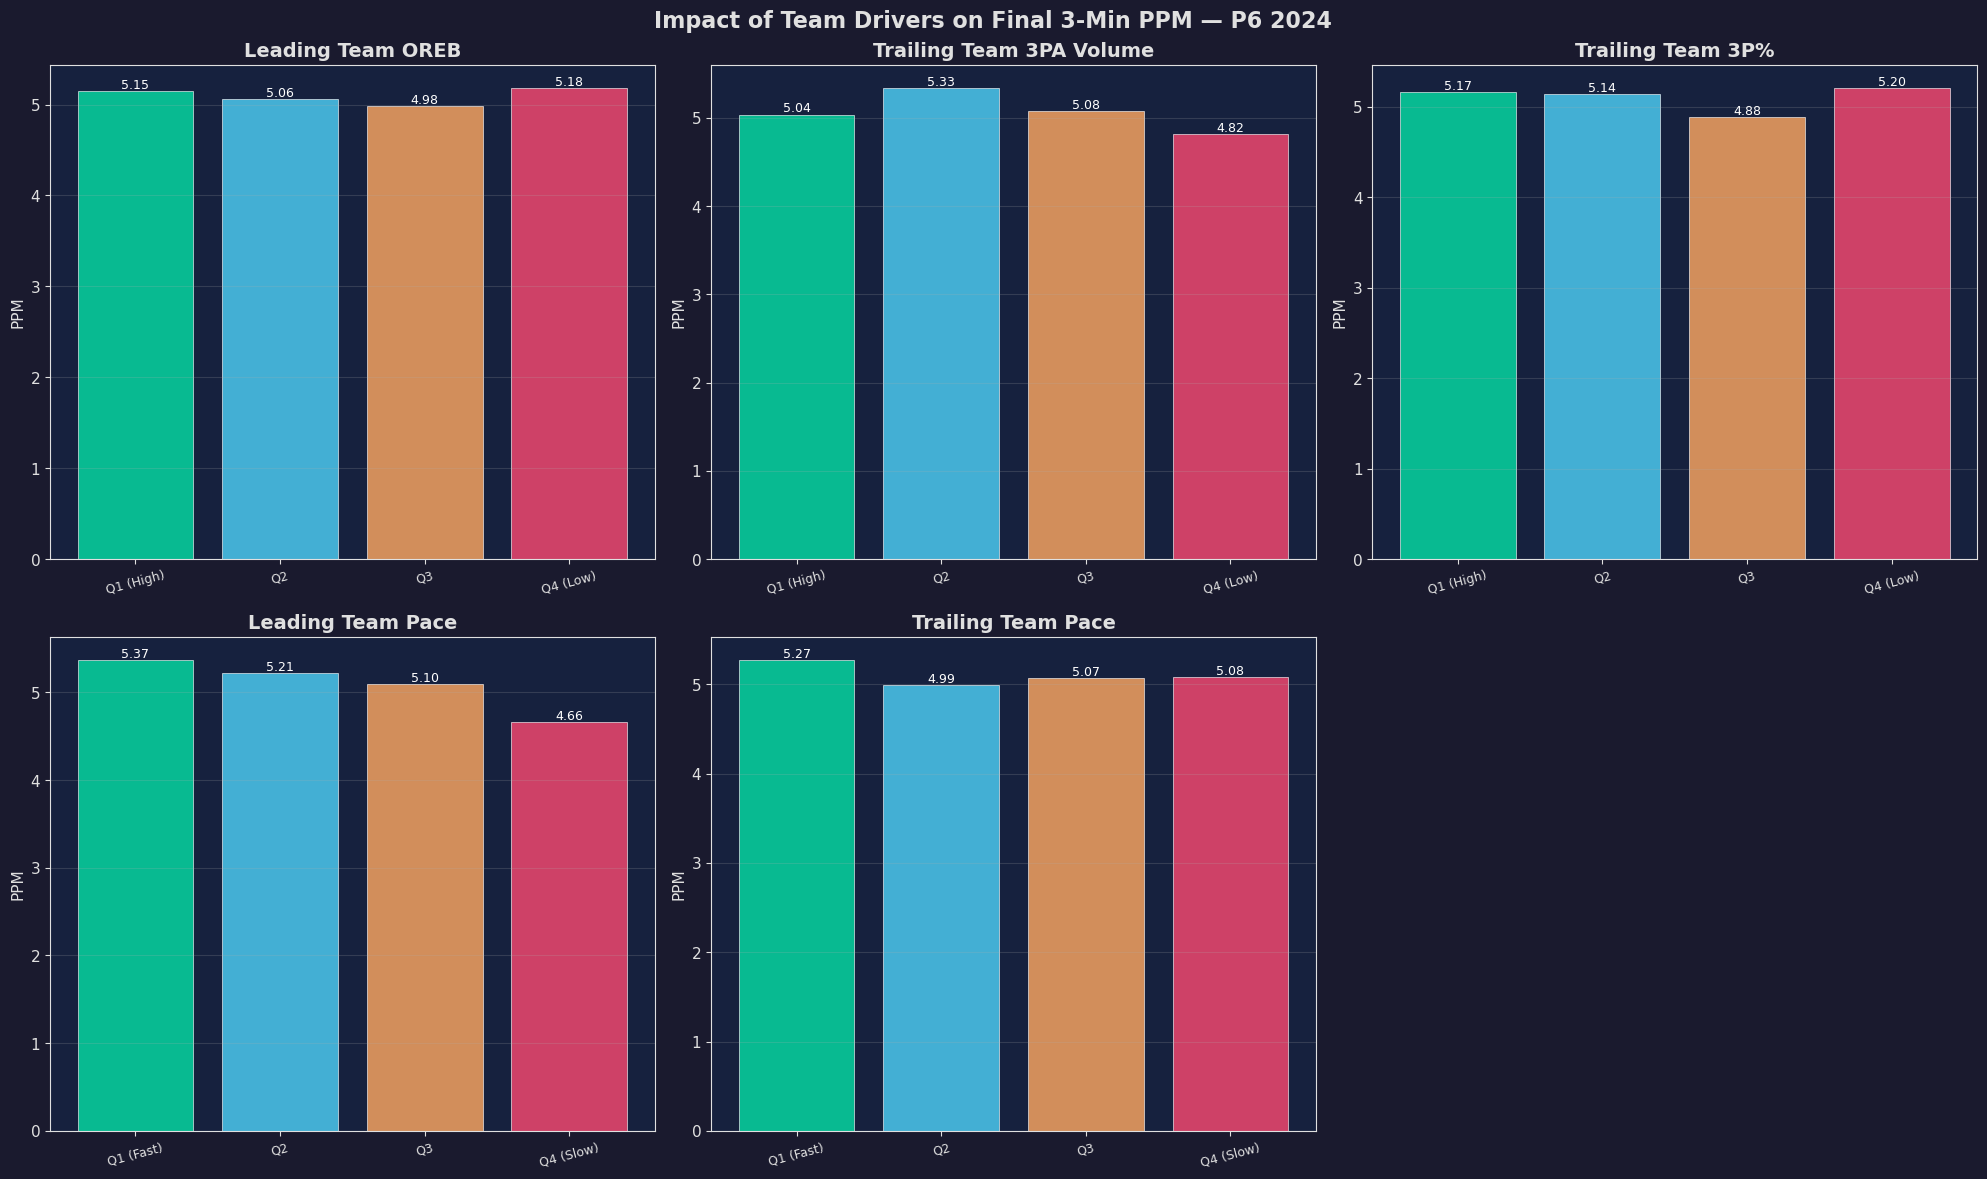

Saved: viz_driver_ppm.png


In [10]:
# ── VIZ 1: PPM by each driver (grouped bar) ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Impact of Team Drivers on Final 3-Min PPM — P6 {SEASON}',
             fontsize=16, fontweight='bold')

driver_colors = ['#06d6a0', '#4cc9f0', '#f4a261', '#ef476f']

for idx, (driver_col, driver_label, q_labels) in enumerate(DRIVER_CONFIGS):
    ax = axes.flat[idx]
    sub = driver_df[driver_df['Driver'] == driver_label]
    ppms = [sub[sub['Quartile'] == q]['PPM'].values[0] for q in q_labels]
    
    bars = ax.bar(range(len(q_labels)), ppms, color=driver_colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(q_labels)))
    ax.set_xticklabels(q_labels, fontsize=9, rotation=15)
    ax.set_ylabel('PPM')
    ax.set_title(driver_label, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    
    for i, v in enumerate(ppms):
        ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, color='white')

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_driver_ppm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_driver_ppm.png')

---
## 7 — Driver × Margin Bucket Profiles

Each of the 5 drivers **individually paired** with **all** point differential buckets.
PPM = total_pts / (games_in_cell × 3 minutes).

In [11]:
# ── PPM by driver quartile x ALL margin buckets for ALL 5 drivers ──
interaction_results = []

for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    s_valid = scoring_3_lt.dropna(subset=[driver_col])
    games_valid = entry_3_lt.dropna(subset=[driver_col])
    
    for b in BUCKET_ORDER:
        s_bucket = s_valid[s_valid['entry_bucket'] == b]
        g_bucket = games_valid[games_valid['margin_bucket'] == b]
        
        for q in q_labels:
            pts = s_bucket[s_bucket[driver_col] == q]['score_value'].sum()
            n_g = (g_bucket[driver_col] == q).sum()
            ppm = pts / (n_g * 3) if n_g > 0 else np.nan
            interaction_results.append({
                'Driver': driver_label, 'Quartile': q,
                'Margin Bucket': b, 'Games': n_g,
                'Total Pts': int(pts),
                'PPM': round(ppm, 3) if not np.isnan(ppm) else np.nan
            })

inter_df = pd.DataFrame(interaction_results)
print(f'Total profiles computed: {len(inter_df)} (5 drivers × {len(BUCKET_ORDER)} buckets × 4 quartiles)')

Total profiles computed: 180 (5 drivers × 9 buckets × 4 quartiles)


In [12]:
# ── TABLE: Driver 1 — Leading Team OREB × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Leading Team OREB']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(BUCKET_ORDER)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(BUCKET_ORDER)

print('=== 1. Leading Team OREB × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 1. Leading Team OREB × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,4.362,4.464,4.372,4.195
Leading 10-15,5.500,5.197,5.720,5.398
Leading 5-9,6.217,5.825,5.417,6.038
Leading 1-4,5.257,4.963,4.808,5.123
Tied,NaN,NaN,NaN,NaN
Trailing 1-4,5.333,4.939,5.253,5.786
Trailing 5-9,5.481,6.020,5.000,5.667
Trailing 10-15,5.264,4.444,4.895,5.941
Trailing >15,4.310,4.822,3.483,3.778



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,80,28,43,41
Leading 10-15,50,22,56,31
Leading 5-9,40,19,32,26
Leading 1-4,35,27,40,27
Tied,0,0,0,0
Trailing 1-4,28,11,33,14
Trailing 5-9,45,17,26,16
Trailing 10-15,29,15,19,17
Trailing >15,29,15,20,12


In [13]:
# ── TABLE: Driver 2 — Trailing Team 3PA Volume × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team 3PA Volume']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(BUCKET_ORDER)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(BUCKET_ORDER)

print('=== 2. Trailing Team 3PA Volume × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 2. Trailing Team 3PA Volume × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,4.453,4.648,4.295,4.023
Leading 10-15,5.632,5.432,5.468,5.654
Leading 5-9,5.275,5.815,6.528,6.000
Leading 1-4,5.078,5.410,4.602,5.048
Tied,NaN,NaN,NaN,NaN
Trailing 1-4,5.275,5.559,4.949,5.175
Trailing 5-9,5.667,5.767,5.278,5.125
Trailing 10-15,4.694,5.750,4.902,4.899
Trailing >15,3.952,4.208,4.833,3.845



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,39,53,43,57
Leading 10-15,29,61,42,27
Leading 5-9,23,45,24,25
Leading 1-4,30,35,36,28
Tied,0,0,0,0
Trailing 1-4,17,37,13,19
Trailing 5-9,22,30,36,16
Trailing 10-15,12,28,17,23
Trailing >15,14,24,10,28


In [14]:
# ── TABLE: Driver 3 — Trailing Team 3P% × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team 3P%']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(BUCKET_ORDER)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(BUCKET_ORDER)

print('=== 3. Trailing Team 3P% × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 3. Trailing Team 3P% × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,4.539,4.530,3.782,4.698
Leading 10-15,5.625,5.153,5.462,6.000
Leading 5-9,5.707,6.011,5.847,6.023
Leading 1-4,5.061,5.128,5.000,4.833
Tied,NaN,NaN,NaN,NaN
Trailing 1-4,5.284,5.479,5.422,5.000
Trailing 5-9,5.108,5.490,5.778,5.867
Trailing 10-15,5.474,4.750,5.350,5.111
Trailing >15,4.375,4.562,3.778,3.933



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
Leading >15,47,44,58,43
Leading 10-15,48,50,31,30
Leading 5-9,33,31,24,29
Leading 1-4,49,26,38,16
Tied,0,0,0,0
Trailing 1-4,27,16,30,13
Trailing 5-9,34,34,21,15
Trailing 10-15,19,20,20,21
Trailing >15,16,16,24,20


In [15]:
# ── TABLE: Driver 4 — Leading Team Pace × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Leading Team Pace']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(BUCKET_ORDER)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(BUCKET_ORDER)

print('=== 4. Leading Team Pace × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 4. Leading Team Pace × Margin Bucket PPM ===
PPM:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
Leading >15,4.673,4.277,4.211,4.164
Leading 10-15,6.085,5.265,5.476,5.235
Leading 5-9,5.833,6.013,6.008,5.638
Leading 1-4,5.190,4.906,5.278,4.617
Tied,NaN,NaN,NaN,NaN
Trailing 1-4,5.536,5.917,4.917,4.978
Trailing 5-9,6.238,5.756,5.111,5.025
Trailing 10-15,4.928,6.167,5.229,4.246
Trailing >15,4.772,4.157,4.097,3.292



Games per cell:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
Leading >15,54,47,38,53
Leading 10-15,39,44,42,34
Leading 5-9,28,26,40,23
Leading 1-4,28,32,42,27
Tied,0,0,0,0
Trailing 1-4,23,20,28,15
Trailing 5-9,21,26,30,27
Trailing 10-15,23,22,16,19
Trailing >15,19,17,24,16


In [16]:
# ── TABLE: Driver 5 — Trailing Team Pace × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team Pace']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(BUCKET_ORDER)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(BUCKET_ORDER)

print('=== 5. Trailing Team Pace × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 5. Trailing Team Pace × Margin Bucket PPM ===
PPM:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
Leading >15,4.738,4.196,4.404,3.899
Leading 10-15,5.667,5.875,5.178,5.547
Leading 5-9,5.284,5.990,6.219,5.947
Leading 1-4,5.444,4.879,5.054,4.827
Tied,NaN,NaN,NaN,NaN
Trailing 1-4,5.492,5.333,5.106,5.392
Trailing 5-9,5.594,4.716,5.889,5.708
Trailing 10-15,5.119,5.017,5.010,5.786
Trailing >15,5.022,3.913,3.944,3.583



Games per cell:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
Leading >15,47,51,61,33
Leading 10-15,34,40,60,25
Leading 5-9,27,33,38,19
Leading 1-4,27,44,31,27
Tied,0,0,0,0
Trailing 1-4,21,26,22,17
Trailing 5-9,23,27,30,24
Trailing 10-15,14,20,32,14
Trailing >15,15,23,30,8


---
## 7b — Heatmap Visualizations (All Drivers × All Buckets)

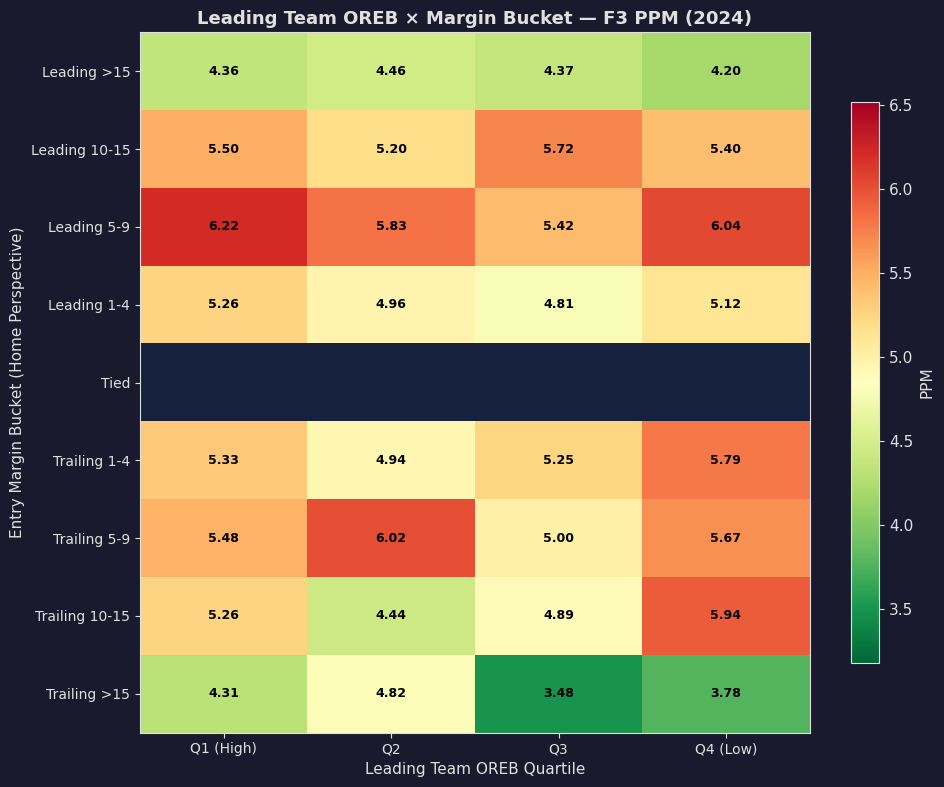

Saved: viz_driver_lead_oreb_q_heatmap.png


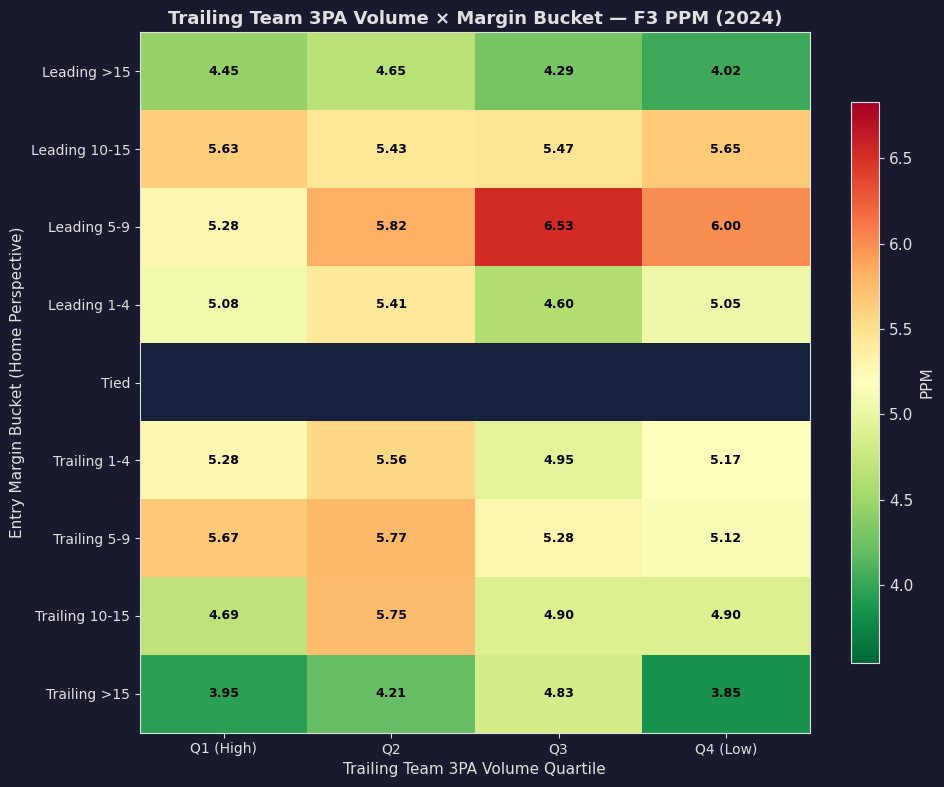

Saved: viz_driver_trail_3pa_q_heatmap.png


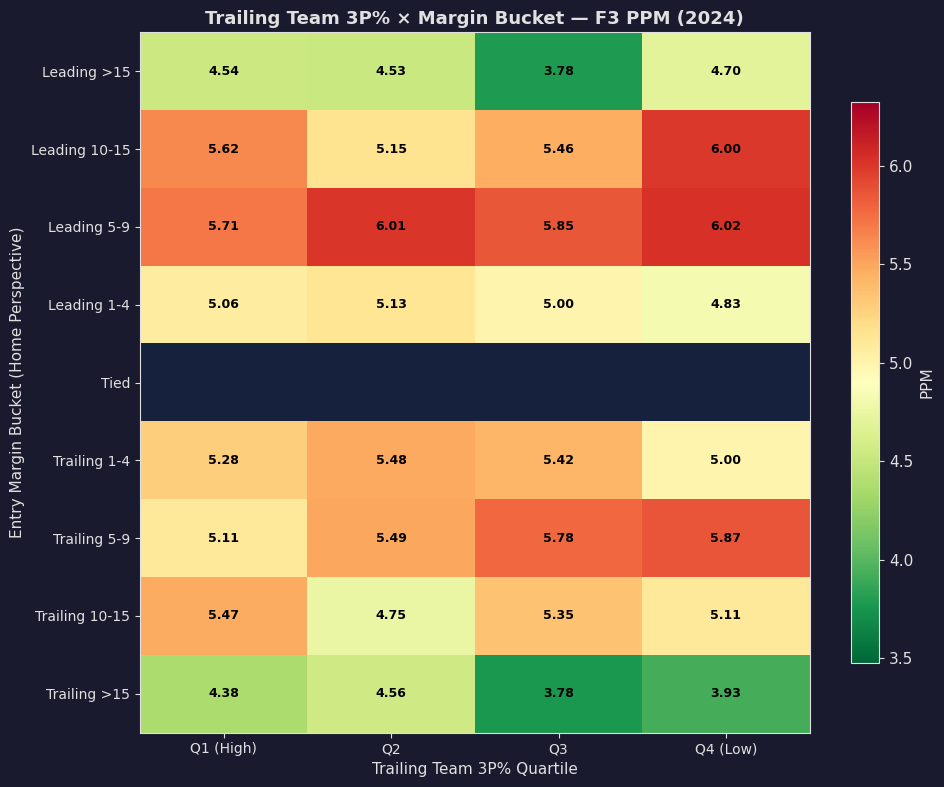

Saved: viz_driver_trail_3p%_q_heatmap.png


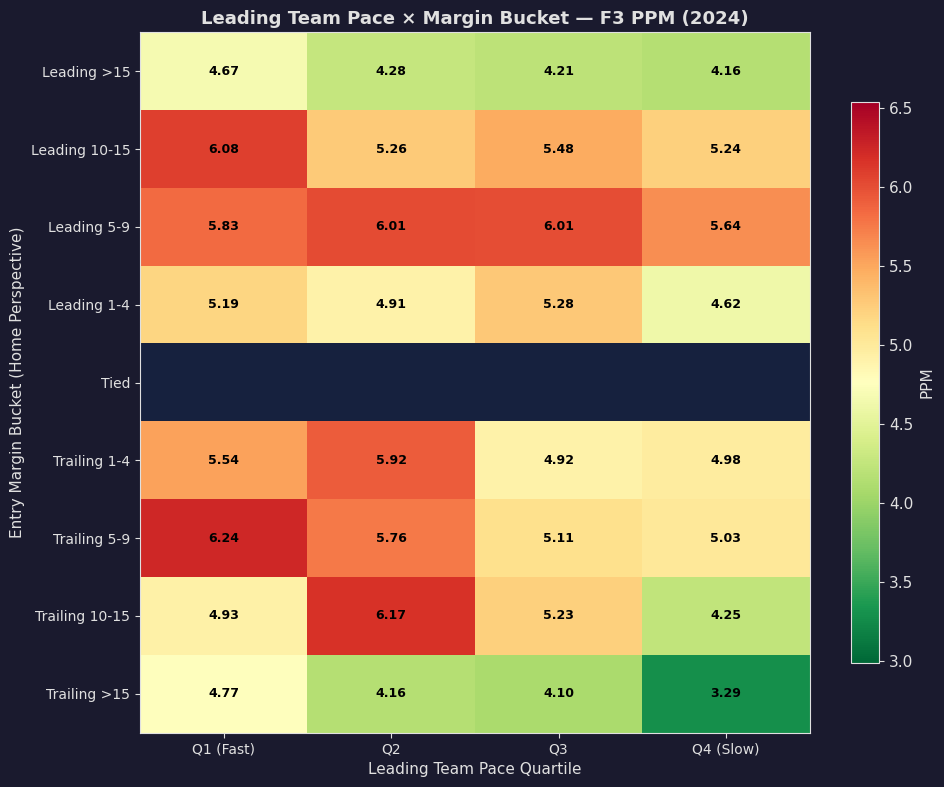

Saved: viz_driver_lead_pace_q_heatmap.png


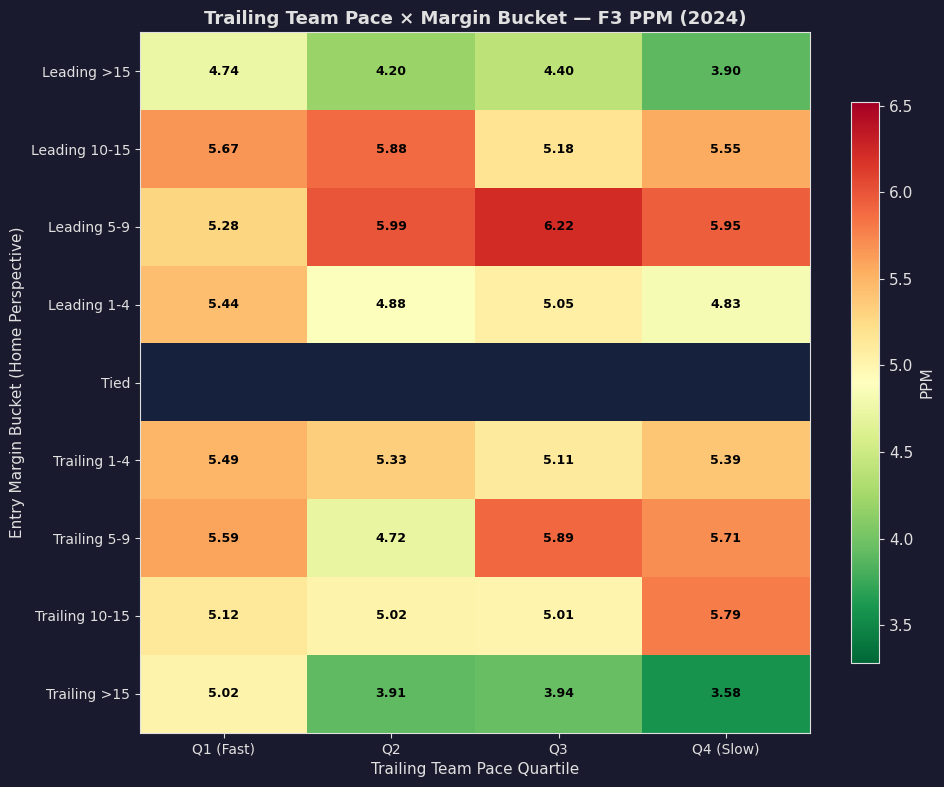

Saved: viz_driver_trail_pace_q_heatmap.png


In [17]:
# ── VIZ: Individual heatmap per driver (5 plots) ──
for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    fig, ax = plt.subplots(figsize=(10, 8))
    d = inter_df[inter_df['Driver'] == driver_label]
    pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                          sort=False).reindex(BUCKET_ORDER)[q_labels]
    
    valid_vals = pivot.values[~np.isnan(pivot.values)]
    if len(valid_vals) == 0:
        continue
    
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=valid_vals.min() - 0.3,
                   vmax=valid_vals.max() + 0.3)
    ax.set_xticks(range(len(q_labels)))
    ax.set_xticklabels(q_labels, fontsize=10)
    ax.set_yticks(range(len(BUCKET_ORDER)))
    ax.set_yticklabels(BUCKET_ORDER, fontsize=10)
    ax.set_xlabel(driver_label + ' Quartile')
    ax.set_ylabel('Entry Margin Bucket (Home Perspective)')
    ax.set_title(f'{driver_label} × Margin Bucket — F3 PPM ({SEASON})',
                 fontweight='bold', fontsize=13)
    
    for i in range(len(BUCKET_ORDER)):
        for j in range(len(q_labels)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=9, color='black', fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='PPM', shrink=0.8)
    plt.tight_layout()
    fname = f'viz_driver_{driver_col.replace(" ", "_").lower()}_heatmap.png'
    plt.savefig(os.path.join(DATA_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

---
## 8 — Combined Driver Effects

Look at games where multiple drivers align (e.g., trailing team with
high 3PA volume AND high 3P%, or leading team with high OREB AND slow pace).

In [18]:
# ── Combined: trailing team 3PA Q1 + 3P% Q1 vs Q4 + Q4 ──
g = entry_3_lt.copy()

# Good trailing shooters: high volume + high efficiency
g['trail_good_shooter'] = (
    (g['trail_3PA Q'] == 'Q1 (High)') & (g['trail_3P% Q'] == 'Q1 (High)')
)
g['trail_poor_shooter'] = (
    (g['trail_3PA Q'] == 'Q4 (Low)') & (g['trail_3P% Q'] == 'Q4 (Low)')
)

# Stalling leaders: high OREB + slow pace
g['lead_stall'] = (
    (g['lead_OREB Q'] == 'Q1 (High)') & (g['lead_Pace Q'] == 'Q4 (Slow)')
)
g['lead_fast_no_boards'] = (
    (g['lead_OREB Q'] == 'Q4 (Low)') & (g['lead_Pace Q'] == 'Q1 (Fast)')
)

combos = {
    'Trail: High 3PA + High 3P%': 'trail_good_shooter',
    'Trail: Low 3PA + Low 3P%':   'trail_poor_shooter',
    'Lead: High OREB + Slow Pace': 'lead_stall',
    'Lead: Low OREB + Fast Pace':  'lead_fast_no_boards',
}

combo_rows = []
for label, col in combos.items():
    game_ids = g[g[col]].index
    n_g = len(game_ids)
    pts = scoring_3_lt[scoring_3_lt['game_id'].isin(game_ids)]['score_value'].sum()
    ppm = pts / (n_g * 3) if n_g > 0 else 0
    combo_rows.append({'Profile': label, 'Games': n_g, 'Total Pts': int(pts),
                       'PPM': round(ppm, 3)})

combo_df = pd.DataFrame(combo_rows)

# Baseline: all non-tied games
baseline_pts = scoring_3_lt['score_value'].sum()
baseline_games = len(entry_3_lt)
baseline_ppm = baseline_pts / (baseline_games * 3)
print(f'Baseline PPM (all non-tied F3): {baseline_ppm:.3f}')

print(f'\n=== Combined Driver Profiles — Final 3 Min PPM ===')
display(combo_df)

Baseline PPM (all non-tied F3): 5.093

=== Combined Driver Profiles — Final 3 Min PPM ===


,Profile,Games,Total Pts,PPM
0,Trail: High 3PA + High 3P%,96,1428,4.958
1,Trail: Low 3PA + Low 3P%,79,1155,4.873
2,Lead: High OREB + Slow Pace,68,938,4.598
3,Lead: Low OREB + Fast Pace,26,472,6.051


---
## 9 — Summary

In [19]:
print('='*60)
print(f'  DRIVER ANALYSIS — {SEASON} Season')
print('='*60)
print(f'\n  P6 games (non-tied at 3:00): {len(entry_3_lt):,}')
print(f'  Drivers analyzed: 5')
print(f'    1. Leading team OREB')
print(f'    2. Trailing team 3PA volume')
print(f'    3. Trailing team 3P% efficiency')
print(f'    4. Leading team pace (sec/poss)')
print(f'    5. Trailing team pace')
print(f'\n  Outputs:')
print(f'    PPM by driver quartile tables')
print(f'    Driver x margin bucket interactions')
print(f'    Combined driver profiles')
print(f'    3 visualizations saved to data/')

  DRIVER ANALYSIS — 2024 Season

  P6 games (non-tied at 3:00): 943
  Drivers analyzed: 5
    1. Leading team OREB
    2. Trailing team 3PA volume
    3. Trailing team 3P% efficiency
    4. Leading team pace (sec/poss)
    5. Trailing team pace

  Outputs:
    PPM by driver quartile tables
    Driver x margin bucket interactions
    Combined driver profiles
    3 visualizations saved to data/
